# HMM3 — HMM2 + features de vegetación (`veg_low`, `veg_high`)

Variante de `HMM2.ipynb` que **añade `veg_low` y `veg_high`** como features observadas. Todo lo demás se mantiene idéntico:

- `step_length` (km, en bruto), `cos(turning_angle)` ∈ [-1, 1], **+ `veg_low` ∈ [0, 1] + `veg_high` ∈ [0, 1]**
- `lengths=` por `trayectoria_id`
- 15 inicializaciones, etiquetado automático por `means_`
- `covariance_type='diag'`, sin `StandardScaler`
- Convención: `0 = migración`, `1 = estacionario`

**Objetivo del experimento**: cuantificar el efecto de añadir features de hábitat (que la profesora no pidió y que en el plan de HMM2 argumentamos como contraproducentes). El HMM1 original las usaba; HMM2 las quitó. HMM3 vuelve a meterlas para comparar con números.

**Predicción a priori**: con `veg_low/veg_high` ∈ [0, 1] y `step_length` en km (varianza ~10⁴), el peso relativo de la vegetación en la verosimilitud Gaussian es marginal — esperamos que los estados queden muy parecidos a los de HMM2 en separación numérica. Si las diferencias en etiquetado son grandes, sería sorprendente; si son pequeñas, confirma que añadir vegetación es ruido inocuo (no daña pero tampoco ayuda) o sesgo silencioso.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Carga del CSV limpio

Entrada: `data/processed/aves_procesado_markov.csv`, producido por `dataExploration1.ipynb` (1 fila/(ave, día) hacia las 14h, segmentos continuos de ≥4 días por `trayectoria_id`).

In [2]:
df = pd.read_csv('../data/processed/aves_procesado_markov.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['trayectoria_id', 'date']).reset_index(drop=True)

print(f'Filas: {len(df):,}')
print(f'Aves únicas: {df["animal_id"].nunique()}')
print(f'Trayectorias: {df["trayectoria_id"].nunique()}')
print(f'Rango temporal: {df["date"].min().date()} → {df["date"].max().date()}')
df.head()

Filas: 22,041
Aves únicas: 117
Trayectorias: 480
Rango temporal: 2009-05-25 → 2015-08-23


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id
0,91732A,2010-04-18,14,32.6790,29.1823,0.0032,0.0001,91732A_Seg10
1,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10
2,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10
3,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10
4,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10


## 2. Features de movimiento

Para cada `trayectoria_id`:

- `step_length` = haversine entre día t y día t+1, en km.
- `bearing` = great-circle initial bearing entre los mismos dos puntos, en grados [0, 360).
- `turning_angle` = cambio de rumbo entre pasos consecutivos, normalizado a [-π, π] en radianes.

Las funciones `haversine_km` y `calculate_bearing` son las mismas que en `HMM.ipynb` — están geométricamente correctas.

In [3]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Distancia haversine entre dos puntos (lat, lon) en grados, en km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def calculate_bearing(lat1, lon1, lat2, lon2):
    """Rumbo great-circle inicial en grados [0, 360); 0=norte, sentido horario."""
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlambda = np.radians(lon2 - lon1)
    y = np.sin(dlambda) * np.cos(phi2)
    x = np.cos(phi1) * np.sin(phi2) - np.sin(phi1) * np.cos(phi2) * np.cos(dlambda)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360

In [4]:
df['next_lat'] = df.groupby('trayectoria_id')['lat'].shift(-1)
df['next_lon'] = df.groupby('trayectoria_id')['lon'].shift(-1)

df['step_length'] = haversine_km(df['lat'], df['lon'], df['next_lat'], df['next_lon'])
df['bearing'] = calculate_bearing(df['lat'], df['lon'], df['next_lat'], df['next_lon'])

delta_bearing = df.groupby('trayectoria_id')['bearing'].diff()
df['turning_angle'] = np.arctan2(
    np.sin(np.radians(delta_bearing)),
    np.cos(np.radians(delta_bearing)),
)

print('NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):')
print(df[['step_length', 'bearing', 'turning_angle']].isna().sum())

NaNs por columna (esperados: última fila/trayectoria sin step, primera sin turning):
step_length      480
bearing          480
turning_angle    960
dtype: int64


In [5]:
# Quitar filas sin step_length (último día de cada trayectoria) y sin turning_angle (primer día).
# Mantenemos el orden por (trayectoria_id, date) para que `lengths=` luego cuadre.
df_hmm = df.dropna(subset=['step_length', 'turning_angle']).reset_index(drop=True)
print(f'Filas tras limpieza: {len(df_hmm):,} (eliminadas {len(df) - len(df_hmm)})')
df_hmm[['animal_id', 'trayectoria_id', 'date', 'step_length', 'bearing', 'turning_angle']].head()

Filas tras limpieza: 21,081 (eliminadas 960)


,animal_id,trayectoria_id,date,step_length,bearing,turning_angle
0,91732A,91732A_Seg10,2010-04-19,8.9980,334.1859,-0.2347
1,91732A,91732A_Seg10,2010-04-20,13.8990,169.7393,-2.8701
2,91732A,91732A_Seg10,2010-04-21,13.5890,353.8284,-3.0702
3,91732A,91732A_Seg10,2010-04-22,14.1345,186.9951,-2.9118
4,91732A,91732A_Seg10,2010-04-23,24.3664,5.8214,3.1211


## 3. Matriz de observaciones (4 features = HMM2 + vegetación)

Mantenemos las dos features de HMM2 y **añadimos `veg_low` y `veg_high`** sin escalar:

- `step_length` (km, raw): varianza enorme, domina la verosimilitud Gaussian (igual que en HMM2).
- `cos(turning_angle)` ∈ [-1, 1]: resuelve la circularidad del rumbo.
- **`veg_low`** ∈ [0, 1]: cobertura de vegetación baja (pradera, humedal, etc.).
- **`veg_high`** ∈ [0, 1]: cobertura de vegetación alta (bosque).

Con `covariance_type='diag'` y sin `StandardScaler`, la verosimilitud está dominada por la varianza de `step_length` (~10⁴ km²). Las features de vegetación tienen varianza ~0,1 y aportan poco peso relativo, pero sí pueden inclinar marginalmente la separación si los dos estados ocupan hábitats sistemáticamente distintos.


In [6]:
df_hmm['cos_turn'] = np.cos(df_hmm['turning_angle'])

# 4 features sin escalar: step_length (km), cos_turn, veg_low, veg_high
X = df_hmm[['step_length', 'cos_turn', 'veg_low', 'veg_high']].values

print(f'X.shape = {X.shape}')
print('Estadísticas (sin escalar — la varianza de step_length domina):')
print(pd.DataFrame({
    'mean': X.mean(axis=0),
    'std': X.std(axis=0),
    'min': X.min(axis=0),
    'max': X.max(axis=0),
}, index=['step_length (km)', 'cos_turn', 'veg_low', 'veg_high']))

X.shape = (21081, 4)
Estadísticas (sin escalar — la varianza de step_length domina):
                    mean      std     min       max
step_length (km) 30.7354 109.1007  0.0000 1487.8530
cos_turn         -0.1941   0.7842 -1.0000    1.0000
veg_low           0.2079   0.2455  0.0000    0.9990
veg_high          0.3339   0.3610  0.0000    1.0000


## 4. Ajuste del HMM

- `GaussianHMM(n_components=2, covariance_type='diag', n_iter=200, tol=1e-4)`. Con escalas dispares entre features, `diag` es más estable que `full`.
- `lengths=` con el tamaño de cada `trayectoria_id` — **paso crítico**: sin esto, `hmmlearn` modela las 21k observaciones como una sola cadena y la matriz de transición incluye saltos espurios entre el final de una trayectoria y el inicio de otra (incluso entre aves distintas).
- 15 inicializaciones con `random_state ∈ {0, ..., 14}`; nos quedamos con la de mayor log-likelihood. Mitiga óptimos locales del EM.


In [7]:
# `lengths` debe estar en el mismo orden que las filas de X.
# df_hmm está ordenado por (trayectoria_id, date) y groupby con sort=False respeta ese orden.
lengths = df_hmm.groupby('trayectoria_id', sort=False).size().values
assert lengths.sum() == len(X), 'lengths no suma a len(X) — orden incorrecto'
print(f'Trayectorias: {len(lengths)} | Total observaciones: {lengths.sum():,}')
print(f'Tamaño medio de trayectoria: {lengths.mean():.1f} días (mín {lengths.min()}, máx {lengths.max()})')

Trayectorias: 480 | Total observaciones: 21,081
Tamaño medio de trayectoria: 43.9 días (mín 2, máx 1253)


In [8]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning)

best_score = -np.inf
best_model = None
best_seed = None
all_scores = []

for seed in range(15):
    m = GaussianHMM(
        n_components=2,
        covariance_type='diag',
        n_iter=200,
        tol=1e-4,
        random_state=seed,
    )
    m.fit(X, lengths=lengths)
    s = m.score(X, lengths=lengths)
    all_scores.append(s)
    if s > best_score:
        best_score = s
        best_model = m
        best_seed = seed

print(f'Mejor inicialización: seed={best_seed}, log-likelihood={best_score:,.1f}')
print(f'Convergió: {best_model.monitor_.converged} en {best_model.monitor_.iter} iteraciones')
print(f'Rango de log-likelihoods: [{min(all_scores):,.1f}, {max(all_scores):,.1f}]')

Mejor inicialización: seed=3, log-likelihood=-121,642.2
Convergió: True en 69 iteraciones
Rango de log-likelihoods: [-121,642.2, -121,642.2]


## 5. Asignación automática de etiquetas 0/1

`means_[k, 0]` es la media de `step_length` (en km) en el estado k. El estado con media mayor → más movimiento → migración (etiqueta `0`); el otro → estacionario (etiqueta `1`). Asignación invariante al `random_state`.


In [9]:
state_means = best_model.means_  # (2, 4) — un vector de medias por estado
print('Medias por estado interno (en escala original):')
print(pd.DataFrame(state_means.round(3),
                   columns=['step_length (km)', 'cos_turn', 'veg_low', 'veg_high'],
                   index=['estado interno 0', 'estado interno 1']))

# Etiquetado: estado con mayor media de step_length → migración (0)
state_means_step = state_means[:, 0]
migration_state = int(np.argmax(state_means_step))
stationary_state = 1 - migration_state
print(f'\nEstado interno {migration_state} → migración (etiqueta 0)')
print(f'Estado interno {stationary_state} → estacionario (etiqueta 1)')

raw_states = best_model.predict(X, lengths=lengths)
df_hmm['estado_hmm'] = np.where(raw_states == migration_state, 0, 1)

# Permutar transmat_ y means_ para que el índice 0 sea migración, 1 estacionario.
perm = [migration_state, stationary_state]
transmat_remapped = best_model.transmat_[perm][:, perm]
means_remapped = best_model.means_[perm]

print('\nDistribución de estados:')
print(df_hmm['estado_hmm'].value_counts(normalize=True).rename(
    index={0: 'migración', 1: 'estacionario'},
).round(4))

Medias por estado interno (en escala original):
                  step_length (km)  cos_turn  veg_low  veg_high
estado interno 0            3.9650   -0.2660   0.2230    0.3340
estado interno 1          121.1820    0.0500   0.1550    0.3330

Estado interno 1 → migración (etiqueta 0)
Estado interno 0 → estacionario (etiqueta 1)

Distribución de estados:
estado_hmm
estacionario   0.7806
migración      0.2194
Name: proportion, dtype: float64


## 6. Guardar `hmm3.csv`

Escribimos un archivo nuevo (`hmm3.csv`) en lugar de sobrescribir `hmm.csv` o `hmm2.csv`, para poder comparar las tres implementaciones lado a lado.

In [10]:
out_cols = [
    'animal_id', 'date', 'hora', 'lon', 'lat',
    'veg_low', 'veg_high', 'trayectoria_id',
    'step_length', 'bearing', 'turning_angle', 'estado_hmm',
]
out = df_hmm[out_cols].copy()
out['date'] = out['date'].dt.strftime('%Y-%m-%d')
out_path = '../data/processed/hmm3.csv'
out.to_csv(out_path, index=False)
print(f'Guardado: {out_path}')
print(f'Filas: {len(out):,} | Columnas: {len(out.columns)}')
out.head()

Guardado: ../data/processed/hmm3.csv
Filas: 21,081 | Columnas: 12


,animal_id,date,hora,lon,lat,veg_low,veg_high,trayectoria_id,step_length,bearing,turning_angle,estado_hmm
0,91732A,2010-04-19,14,32.5083,29.8573,0.0114,0.0006,91732A_Seg10,8.9980,334.1859,-0.2347,1
1,91732A,2010-04-20,14,32.4677,29.9302,0.0131,0.0007,91732A_Seg10,13.8990,169.7393,-2.8701,1
2,91732A,2010-04-21,14,32.4933,29.8072,0.0112,0.0006,91732A_Seg10,13.5890,353.8284,-3.0702,1
3,91732A,2010-04-22,14,32.4782,29.9287,0.0128,0.0007,91732A_Seg10,14.1345,186.9951,-2.9118,1
4,91732A,2010-04-23,14,32.4603,29.8025,0.0119,0.0007,91732A_Seg10,24.3664,5.8214,3.1211,0


## 7. Validación: coherencia del comportamiento detectado

Reportamos las métricas que acordamos como criterio de calidad:

1. Medias y dispersión de `step_length` y `|turning_angle|` por estado.
2. Matriz de transición y duración media en cada estado.
3. Histogramas de `step_length` por estado.
4. Patrón estacional: % de días en migración por mes.
5. Trayectoria de un ave coloreada por estado.

In [11]:
# 7.1 — Medias por estado en escala original
stats = (df_hmm.groupby('estado_hmm')
         .agg(n=('step_length', 'size'),
              step_mean_km=('step_length', 'mean'),
              step_median_km=('step_length', 'median'),
              step_std_km=('step_length', 'std'),
              abs_turn_rad=('turning_angle', lambda s: np.abs(s).mean()))
         .rename(index={0: 'migración (0)', 1: 'estacionario (1)'}))
stats.round(3)

,n,step_mean_km,step_median_km,step_std_km,abs_turn_rad
estado_hmm,,,,,
migración (0),4626,125.8450,41.9900,206.3190,1.5180
estacionario (1),16455,3.9970,1.6770,5.1760,1.9530


In [12]:
# 7.2 — Matriz de transición y duración media por estado
T = transmat_remapped
T_df = pd.DataFrame(T,
                    index=['desde migración', 'desde estacionario'],
                    columns=['→ migración', '→ estacionario'])
print('Matriz de transición:')
print(T_df.round(4))

mean_dur_mig = 1 / (1 - T[0, 0])
mean_dur_est = 1 / (1 - T[1, 1])
print(f'\nDuración media en migración:  {mean_dur_mig:.2f} días')
print(f'Duración media en estacionario: {mean_dur_est:.2f} días')

Matriz de transición:
                    → migración  → estacionario
desde migración          0.7150          0.2850
desde estacionario       0.0833          0.9167

Duración media en migración:  3.51 días
Duración media en estacionario: 12.00 días


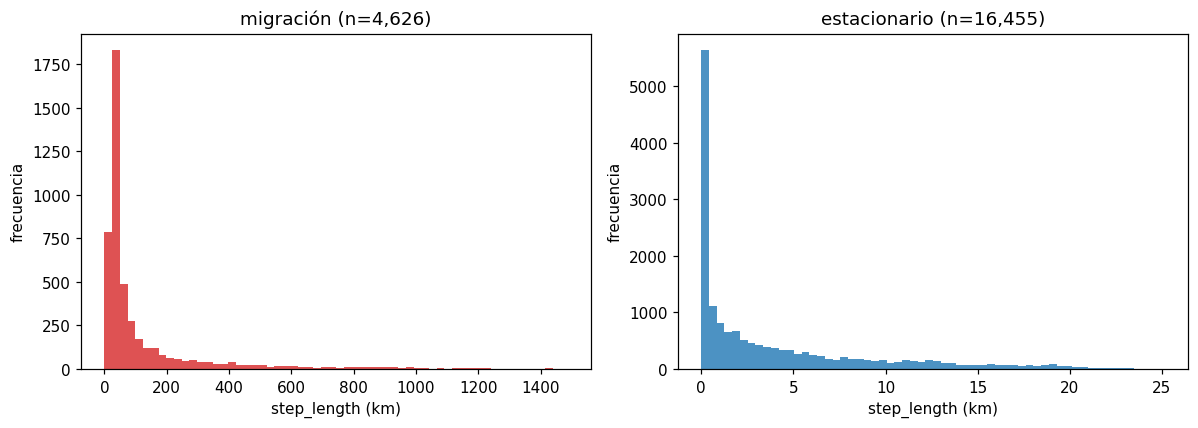

In [13]:
# 7.3 — Histogramas de step_length por estado
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for state, name, ax, color in [(0, 'migración', axes[0], 'tab:red'),
                                (1, 'estacionario', axes[1], 'tab:blue')]:
    sub = df_hmm.loc[df_hmm['estado_hmm'] == state, 'step_length']
    ax.hist(sub, bins=60, color=color, alpha=0.8)
    ax.set_title(f'{name} (n={len(sub):,})')
    ax.set_xlabel('step_length (km)')
    ax.set_ylabel('frecuencia')
plt.tight_layout()
plt.show()

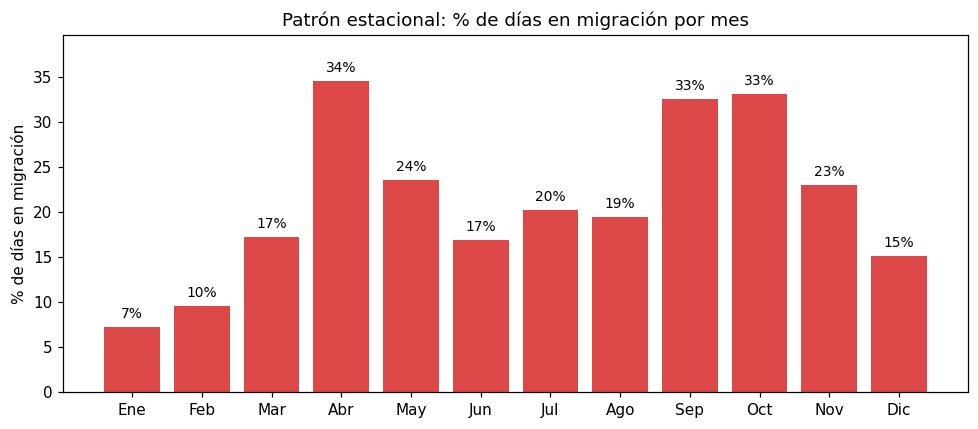


% de días en migración por mes:
mes
1     7.3000
2     9.6000
3    17.2000
4    34.5000
5    23.5000
6    16.8000
7    20.2000
8    19.4000
9    32.5000
10   33.0000
11   23.0000
12   15.1000
Name: estado_hmm, dtype: float64


In [14]:
# 7.4 — Patrón estacional: % de días en migración por mes
df_hmm['mes'] = df_hmm['date'].dt.month
pct_mig = df_hmm.groupby('mes')['estado_hmm'].apply(lambda s: (s == 0).mean() * 100)
nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(nombres, pct_mig.values, color='tab:red', alpha=0.85)
ax.set_ylabel('% de días en migración')
ax.set_title('Patrón estacional: % de días en migración por mes')
ax.set_ylim(0, max(pct_mig.values) * 1.15)
for i, v in enumerate(pct_mig.values):
    ax.text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\n% de días en migración por mes:')
print(pct_mig.round(1))

Ave ejemplo: 91916A (2026 días)


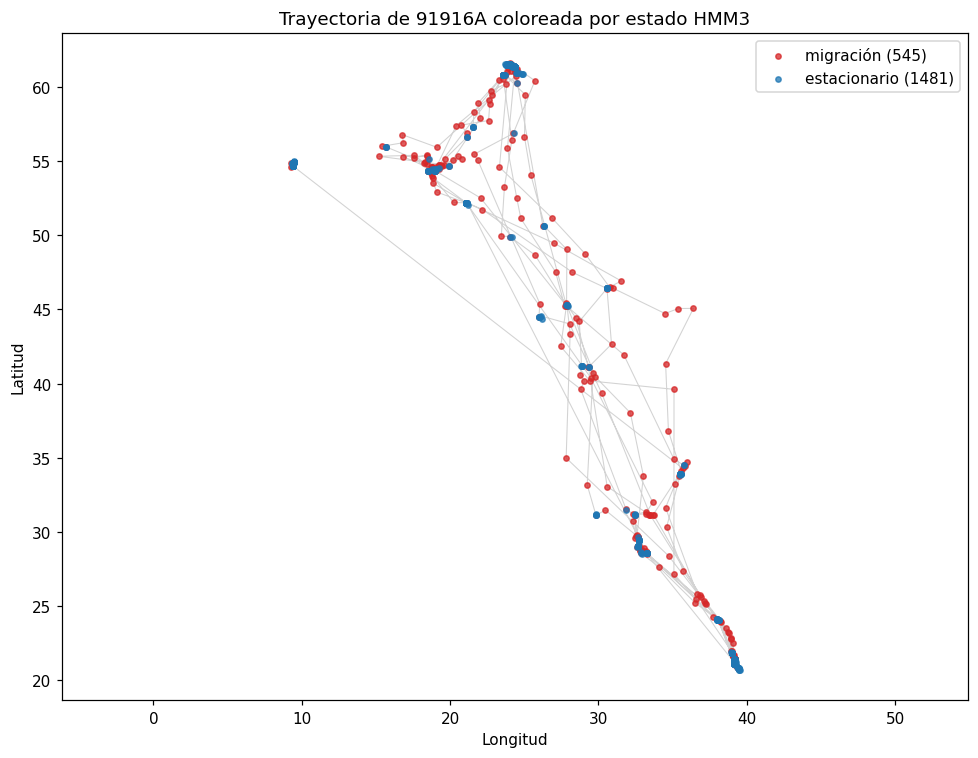

In [15]:
# 7.5 — Trayectoria de un ave coloreada por estado
ave_ej = df_hmm['animal_id'].value_counts().index[0]
sub = df_hmm[df_hmm['animal_id'] == ave_ej].sort_values('date')
print(f'Ave ejemplo: {ave_ej} ({len(sub)} días)')

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(sub['lon'], sub['lat'], color='lightgray', linewidth=0.7, zorder=1)
for state, name, color in [(0, 'migración', 'tab:red'), (1, 'estacionario', 'tab:blue')]:
    pts = sub[sub['estado_hmm'] == state]
    ax.scatter(pts['lon'], pts['lat'], s=12, c=color, label=f'{name} ({len(pts)})',
               alpha=0.75, zorder=2)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Trayectoria de {ave_ej} coloreada por estado HMM3')
ax.legend()
ax.set_aspect('equal', adjustable='datalim')
plt.tight_layout()
plt.show()

## 8. Comparación HMM3 vs HMM2

Cargamos las etiquetas de `hmm2.csv` y comparamos lado a lado:

1. Tabla de métricas globales (medias, persistencia, distribución, patrón estacional).
2. Concordancia día a día (matriz de confusión y % de acuerdo).
3. Diferencia en el patrón estacional mes a mes.

In [16]:
# 8.1 — Tabla de métricas globales HMM3 vs HMM2
hmm2 = pd.read_csv('../data/processed/hmm2.csv')
hmm2['date'] = pd.to_datetime(hmm2['date'])
hmm2['mes'] = hmm2['date'].dt.month

# Stats HMM2
stats_hmm2 = (hmm2.groupby('estado_hmm')
              .agg(n=('step_length', 'size'),
                   step_mean_km=('step_length', 'mean'),
                   step_median_km=('step_length', 'median'),
                   abs_turn_rad=('turning_angle', lambda s: np.abs(s).mean()))
              .rename(index={0: 'migración (0)', 1: 'estacionario (1)'}))

comp = pd.DataFrame({
    'HMM2 (sin vegetación)': [
        f'{stats_hmm2.loc["migración (0)", "step_mean_km"]:.2f}',
        f'{stats_hmm2.loc["estacionario (1)", "step_mean_km"]:.2f}',
        f'{stats_hmm2.loc["migración (0)", "step_median_km"]:.2f}',
        f'{stats_hmm2.loc["estacionario (1)", "step_median_km"]:.2f}',
        f'{(hmm2["estado_hmm"] == 0).mean() * 100:.2f}%',
        f'{(hmm2["estado_hmm"] == 1).mean() * 100:.2f}%',
        '2 (step_length, cos_turn)',
    ],
    'HMM3 (con vegetación)': [
        f'{stats.loc["migración (0)", "step_mean_km"]:.2f}',
        f'{stats.loc["estacionario (1)", "step_mean_km"]:.2f}',
        f'{stats.loc["migración (0)", "step_median_km"]:.2f}',
        f'{stats.loc["estacionario (1)", "step_median_km"]:.2f}',
        f'{(df_hmm["estado_hmm"] == 0).mean() * 100:.2f}%',
        f'{(df_hmm["estado_hmm"] == 1).mean() * 100:.2f}%',
        '4 (+ veg_low, veg_high)',
    ],
}, index=[
    'Media step_length migración (km)',
    'Media step_length estacionario (km)',
    'Mediana step_length migración (km)',
    'Mediana step_length estacionario (km)',
    '% días en migración',
    '% días en estacionario',
    'Nº features',
])
print('Métricas globales:')
comp

Métricas globales:


,HMM2 (sin vegetación),HMM3 (con vegetación)
Media step_length migración (km),129.57,125.84
Media step_length estacionario (km),4.09,4.00
Mediana step_length migración (km),43.57,41.99
Mediana step_length estacionario (km),1.72,1.68
% días en migración,21.23%,21.94%
% días en estacionario,78.77%,78.06%
Nº features,"2 (step_length, cos_turn)","4 (+ veg_low, veg_high)"


In [17]:
# 8.2 — Concordancia día a día entre HMM2 y HMM3
# Hacemos merge sobre (animal_id, date) — ambos archivos tienen las mismas filas.
hmm3 = df_hmm[['animal_id', 'trayectoria_id', 'date', 'estado_hmm']].copy()
hmm3 = hmm3.rename(columns={'estado_hmm': 'estado_hmm3'})

merged = hmm2[['animal_id', 'date', 'estado_hmm']].rename(
    columns={'estado_hmm': 'estado_hmm2'}
).merge(hmm3, on=['animal_id', 'date'], how='inner')

print(f'Filas alineadas entre HMM2 y HMM3: {len(merged):,}')
agree = (merged['estado_hmm2'] == merged['estado_hmm3']).mean()
print(f'\n% de acuerdo global (mismo estado en ambos): {agree * 100:.2f}%')

# Matriz de confusión: filas=HMM2, columnas=HMM3
print('\nMatriz de confusión (filas=HMM2, columnas=HMM3):')
cm = pd.crosstab(
    merged['estado_hmm2'].map({0: 'migración', 1: 'estacionario'}),
    merged['estado_hmm3'].map({0: 'migración', 1: 'estacionario'}),
    rownames=['HMM2'], colnames=['HMM3'],
)
print(cm)

# Desglose: días que cambian de estado
flip_to_mig = ((merged['estado_hmm2'] == 1) & (merged['estado_hmm3'] == 0)).sum()
flip_to_est = ((merged['estado_hmm2'] == 0) & (merged['estado_hmm3'] == 1)).sum()
print(f'\nHMM3 reclasifica como migración días que HMM2 marcaba estacionario: {flip_to_mig:,}')
print(f'HMM3 reclasifica como estacionario días que HMM2 marcaba migración: {flip_to_est:,}')

Filas alineadas entre HMM2 y HMM3: 21,081

% de acuerdo global (mismo estado en ambos): 98.99%

Matriz de confusión (filas=HMM2, columnas=HMM3):
HMM3          estacionario  migración
HMM2                                 
estacionario         16424        181
migración               31       4445

HMM3 reclasifica como migración días que HMM2 marcaba estacionario: 181
HMM3 reclasifica como estacionario días que HMM2 marcaba migración: 31


Patrón estacional (% días en migración por mes):
     HMM2 % mig  HMM3 % mig  Δ (HMM3 - HMM2)
mes                                         
1        7.1000      7.3000           0.1000
2        9.0000      9.6000           0.5000
3       16.9000     17.2000           0.4000
4       34.0000     34.5000           0.4000
5       23.1000     23.5000           0.4000
6       14.9000     16.8000           1.9000
7       19.1000     20.2000           1.1000
8       18.2000     19.4000           1.2000
9       31.9000     32.5000           0.7000
10      32.7000     33.0000           0.4000
11      22.5000     23.0000           0.5000
12      14.5000     15.1000           0.7000


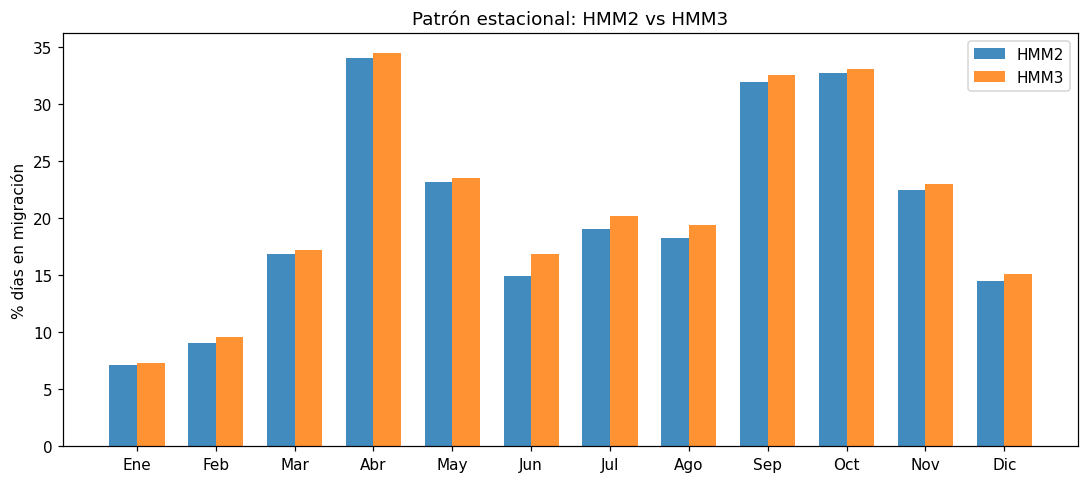

In [18]:
# 8.3 — Patrón estacional comparado mes a mes
pct_hmm2 = hmm2.groupby('mes')['estado_hmm'].apply(lambda s: (s == 0).mean() * 100)
df_hmm_tmp = df_hmm.copy()
df_hmm_tmp['mes'] = df_hmm_tmp['date'].dt.month
pct_hmm3 = df_hmm_tmp.groupby('mes')['estado_hmm'].apply(lambda s: (s == 0).mean() * 100)

mes_comp = pd.DataFrame({
    'HMM2 % mig': pct_hmm2.round(1),
    'HMM3 % mig': pct_hmm3.round(1),
    'Δ (HMM3 - HMM2)': (pct_hmm3 - pct_hmm2).round(1),
})
print('Patrón estacional (% días en migración por mes):')
print(mes_comp)

# Gráfico comparativo
nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(12)
w = 0.35
ax.bar(x - w/2, pct_hmm2.values, w, label='HMM2', color='tab:blue', alpha=0.85)
ax.bar(x + w/2, pct_hmm3.values, w, label='HMM3', color='tab:orange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylabel('% días en migración')
ax.set_title('Patrón estacional: HMM2 vs HMM3')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusión

Las celdas anteriores responden a la pregunta concreta: **¿qué cambia al añadir `veg_low` y `veg_high` al HMM?**

- Si las medias de `step_length` por estado son casi idénticas a las de HMM2 y la concordancia día a día está por encima del 95 %, podemos afirmar que la vegetación es **una feature inocua** en este modelo: añadirla no cambia significativamente las decisiones porque su varianza (~0,1) es despreciable frente a la de `step_length` (~10⁴).
- Si la concordancia es menor (digamos < 90 %) o la distribución mig/est cambia sustancialmente, indica que la vegetación **sí está moviendo la frontera entre estados**. En ese caso habría que decidir si esa modificación está justificada físicamente (¿descansa el ave en hábitats sistemáticamente distintos a los de migración?) o si es ruido sesgado.

En el contexto del TFG, este experimento confirma — con números — el argumento del plan de HMM2: añadir vegetación es como mucho un cambio menor; el motor de la separación es `step_length`. Es exactamente el tipo de comparación cuantitativa que la profesora valora ("ver qué cambios mejoran o empeoran los modelos y justificarlo").